<a href="https://colab.research.google.com/github/achyutmorang/waymax-simulation-experiments/blob/main/experiments/risk-uq-suite/notebooks/10_decision_audit/cross_signal_decision_audit_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Open In Colab

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achyutmorang/waymax-simulation-experiments/blob/main/experiments/risk-uq-suite/notebooks/10_decision_audit/cross_signal_decision_audit_colab.ipynb)


# Cross-Signal Decision Audit (Colab)

## Objective
Audit candidate-level uncertainty/risk signals as **decision objects** under thresholded control.

This notebook evaluates whether each signal is decision-grade for `failure_proxy_h15`, comparing:
- raw score
- Platt-calibrated score
- isotonic-calibrated score (when available)


## Hypotheses Tested

1. At least one planner-side proxy carries candidate-level discriminative signal.
2. Post-hoc calibration (Platt; isotonic when available) improves probability reliability metrics.
3. Thresholded decisions (`p <= tau`) can fail via false-safe, safe-reject, or feasible-set collapse.
4. Decision quality differs between nominal and shifted splits.
5. Method-inspired risk formulations (RACP-style, chance-constraint-style, reachability-style) behave differently across planner variants.


## Step 1 - Deterministic Bootstrap Constants


In [20]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/achyutmorang/waymax-simulation-experiments.git'
REPO_DIR = '/content/waymax-simulation-experiments'
REPO_BRANCH = 'main'
EXPERIMENT_SLUG = 'risk-uq-suite'
EXPERIMENT_CONFIG_PATH = f'{REPO_DIR}/configs/experiments/{EXPERIMENT_SLUG}.json'
REQUIRED_DRIVE_FOLDER = '/content/drive/MyDrive/waymax_experiments'

NOTEBOOK_NAME = 'cross_signal_decision_audit_colab'

runtime_cfg_overrides = {
    'verify_drive_access_every_run': False,
    'force_reinstall': False,
    'auto_restart_after_setup': True,
    'strict_lockfile_check': True,
    'setup_cache_enabled': True,
    'revalidate_core_imports_on_cache_hit': True,
    'setup_cache_path': '/content/.closedloop_setup_cache.json',
    'force_module_hot_reload': True,
}

content_root = Path('/content')
content_root.mkdir(parents=True, exist_ok=True)
try:
    _ = os.getcwd()
except FileNotFoundError:
    os.chdir(str(content_root))


## Step 2 - Storage Setup


In [21]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as exc:
    print('[storage] google.colab drive mount unavailable:', exc)

drive_root = Path('/content/drive/MyDrive')
if not drive_root.exists():
    raise RuntimeError('Drive root not found at /content/drive/MyDrive. Ensure Google Drive is mounted.')

required_root = Path(REQUIRED_DRIVE_FOLDER)
required_root.mkdir(parents=True, exist_ok=True)
probe = required_root / '.risk_uq_storage_probe'
probe.write_text('ok')
probe.unlink(missing_ok=True)
print('[storage] ready:', required_root)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[storage] ready: /content/drive/MyDrive/waymax_experiments


## Step 3 - Repo Sync + Runtime Bootstrap


In [22]:
if not Path(REPO_DIR).exists():
    subprocess.run(['git', 'clone', '--depth', '1', '-b', REPO_BRANCH, REPO_URL, REPO_DIR], check=True)

for p in (REPO_DIR, f'{REPO_DIR}/src'):
    if p not in sys.path:
        sys.path.insert(0, p)

from src.platform import ColabRuntimeConfig, bootstrap_colab_runtime_with_config

runtime_cfg = ColabRuntimeConfig(
    repo_url=REPO_URL,
    repo_dir=REPO_DIR,
    repo_branch=REPO_BRANCH,
    required_drive_folder=REQUIRED_DRIVE_FOLDER,
    **runtime_cfg_overrides,
)
bootstrap = bootstrap_colab_runtime_with_config(runtime_cfg)

globals()['_RISK_UQ_REPO_REV'] = str(bootstrap.repo_sync.repo_rev)
setup_result = bootstrap.setup.result

print('Working directory:', os.getcwd())
print('Repo commit:', bootstrap.repo_sync.repo_rev)
print('Drive mounted:', bootstrap.drive_status.mounted)
print('[setup] result:', setup_result)
if bool(setup_result.get('restart_required', False)) and (not bool(runtime_cfg.auto_restart_after_setup)):
    print('[setup] restart_required=True. Re-run this notebook after runtime restart.')


[repo] existing checkout: /content/waymax-simulation-experiments
[drive] /content/drive already mounted
[drive] Verified read/write access: /content/drive/MyDrive/waymax_experiments
[setup] cache hit -> skipping deterministic setup: ok numpy=2.2.6 pandas=2.2.3
[setup] cached ready state at /content/.closedloop_setup_cache.json
Working directory: /content/waymax-simulation-experiments
Repo commit: 8f73990
Drive mounted: True
[setup] result: {'ran_setup': False, 'cache_hit': True, 'cache_reason': 'fingerprint_match', 'restart_required': False, 'core_probe': 'ok numpy=2.2.6 pandas=2.2.3', 'kernel_executable': '/usr/bin/python3'}


## Step 4 - Configuration + Run Context


In [23]:
from src.workflows import (
    initialize_risk_uq_run_context,
    load_experiment_config,
    report_risk_uq_run_context,
)

EXPERIMENT_CFG = load_experiment_config(
    slug=EXPERIMENT_SLUG,
    repo_root=REPO_DIR,
    default_on_missing=False,
)
run_cfg = dict(EXPERIMENT_CFG.get('run', {}))

RUN_NAME = str(run_cfg.get('run_name', '')).strip()
RUN_PREFIX = str(run_cfg.get('run_prefix', 'risk_uq')).strip() or 'risk_uq'
PERSIST_ROOT = str(run_cfg.get('persist_root', '/content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1')).strip()
N_SHARDS = int(max(1, int(run_cfg.get('n_shards', 1))))
SHARD_ID = run_cfg.get('shard_id', 'auto')
RESUME_FROM_EXISTING = bool(run_cfg.get('resume_from_existing', True))
RUN_ENABLED = bool(run_cfg.get('run_enabled', True))

RUN_TAG_PREFIX = str(run_cfg.get('run_tag_prefix', RUN_PREFIX)).strip() or RUN_PREFIX
RUN_MODE_CFG = str(run_cfg.get('run_mode', 'auto')).strip().lower() or 'auto'
RUN_MODE = RUN_MODE_CFG if RESUME_FROM_EXISTING else 'fresh'
RUN_TAG = RUN_NAME

run_ctx = initialize_risk_uq_run_context(
    run_tag=RUN_TAG,
    run_tag_prefix=RUN_TAG_PREFIX,
    persist_root=PERSIST_ROOT,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    resume_mode=RUN_MODE,
    resume_from_existing=bool(RESUME_FROM_EXISTING),
    planner_backend='latentdriver',
)

cfg = run_ctx.cfg
search_cfg = {}
RUN_TAG = str(run_ctx.run_tag)
RUN_NAME = str(RUN_NAME or RUN_TAG)
SHARD_ID = int(run_ctx.shard_id)

print('EXPERIMENT_CONFIG_PATH =', EXPERIMENT_CONFIG_PATH)
print('run_prefix (flat artifacts) =', cfg.run_prefix)
print('RUN_PREFIX/RUN_NAME (contract dir) =', RUN_PREFIX, RUN_NAME)
print('RUN_ENABLED =', RUN_ENABLED, ' RESUME_FROM_EXISTING =', RESUME_FROM_EXISTING)
report_risk_uq_run_context(run_ctx, display_fn=display)

FOCUS_LABEL = str(run_cfg.get('focus_label', 'failure_proxy_h15'))
RISK_BUDGET_TAU = float(run_cfg.get('risk_budget_tau', 0.20))
TAU_SWEEP_VALUES = [round(float(x), 3) for x in list(__import__('numpy').linspace(0.05, 0.80, 16))]
BOOTSTRAP_SAMPLES = int(run_cfg.get('decision_bootstrap_samples', 300))
BOOTSTRAP_SEED = int(run_cfg.get('decision_bootstrap_seed', 17))
LOCAL_TAU_WINDOW = float(run_cfg.get('local_tau_window', 0.05))

cfg.uq_eval_probability_bins = int(max(10, int(getattr(cfg, 'uq_eval_probability_bins', 15))))


[config auto-fix] latentdriver_context_len increased from 2 to 10 to match history_steps.
[ckpt] using configured checkpoint: /content/checkpoints/lantentdriver_t2_J3.ckpt
[ckpt] final cfg.latentdriver_ckpt_path = /content/checkpoints/lantentdriver_t2_J3.ckpt
EXPERIMENT_CONFIG_PATH = /content/waymax-simulation-experiments/configs/experiments/risk-uq-suite.json
run_prefix (flat artifacts) = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260301_043750
RUN_PREFIX/RUN_NAME (contract dir) = risk_uq risk_uq_20260301_043750
RUN_ENABLED = True  RESUME_FROM_EXISTING = True


,field,value
0,run_tag,risk_uq_20260301_043750
1,run_prefix,/content/drive/MyDrive/waymax_experiments/risk...
2,run_mode,auto
3,planner_backend,latentdriver
4,persist_root,/content/drive/MyDrive/waymax_experiments/risk...
5,n_shards,1
6,shard_id,0
7,resume_from_existing,1
8,latentdriver_ckpt_path,/content/checkpoints/lantentdriver_t2_J3.ckpt


,path,name,size_mb,mtime_utc,root,root_rank,name_score,score
0,/content/checkpoints/lantentdriver_t2_J3.ckpt,lantentdriver_t2_J3.ckpt,116.742193,2026-03-01T04:07:34Z,/content/checkpoints,0,100,100100.011674


## Step 5 - Locate and Load Probe Artifacts


In [24]:
import pandas as pd
from pathlib import Path
from src.workflows import (
    discover_probe_run_prefixes,
    has_existing_miscalibration_probe_artifacts,
    load_existing_miscalibration_probe_bundle,
)

def _parse_prefix_list(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        out = []
        for x in value:
            sx = str(x).strip()
            if sx:
                out.append(sx)
        return out
    text = str(value).strip()
    if not text:
        return []
    text = text.replace(chr(10), ',').replace(';', ',')
    return [p.strip() for p in text.split(',') if p.strip()]

def _normalize_planner_variant(df, run_prefix):
    local = df.copy()
    run_tag = Path(str(run_prefix)).name

    planner_col_candidates = [
        str(run_cfg.get('planner_variant_column', '')).strip(),
        'planner_variant',
        'planner_backend',
        'planner_kind',
        'planner_used',
    ]
    planner_col_candidates = [c for c in planner_col_candidates if c]

    planner_series = None
    for col in planner_col_candidates:
        if col in local.columns:
            s = local[col].astype(str).str.strip()
            if (s != '').any():
                planner_series = s
                break

    if planner_series is None:
        planner_series = pd.Series([f'run:{run_tag}'] * len(local), index=local.index, dtype='object')
    else:
        planner_series = planner_series.where(planner_series.str.len() > 0, f'run:{run_tag}')

    local['planner_variant'] = planner_series.astype(str)
    local['analysis_run_prefix'] = str(run_prefix)
    local['analysis_run_tag'] = str(run_tag)
    return local

ANALYSIS_RUN_PREFIX_OVERRIDE = str(run_cfg.get('analysis_run_prefix', '')).strip()
ANALYSIS_RUN_PREFIXES = _parse_prefix_list(run_cfg.get('analysis_run_prefixes', []))
MAX_DISCOVERED_RUNS = int(max(1, int(run_cfg.get('max_discovered_probe_runs', 50))))
MAX_RUNS_TO_LOAD = int(max(1, int(run_cfg.get('max_probe_runs_to_load', 8))))

requested_prefixes = []
if ANALYSIS_RUN_PREFIX_OVERRIDE:
    requested_prefixes.append(ANALYSIS_RUN_PREFIX_OVERRIDE)
requested_prefixes.extend(ANALYSIS_RUN_PREFIXES)
if len(requested_prefixes) == 0:
    requested_prefixes.append(str(cfg.run_prefix))

# Keep order stable and unique.
seen = set()
requested_prefixes = [p for p in requested_prefixes if not (p in seen or seen.add(p))]

discovered_runs_df = discover_probe_run_prefixes(PERSIST_ROOT, limit=MAX_DISCOVERED_RUNS)
if not discovered_runs_df.empty:
    print('[artifacts] discovered probe runs (most recent first):')
    display(discovered_runs_df.head(20))
else:
    print('[artifacts] no probe runs discovered under PERSIST_ROOT:', PERSIST_ROOT)

ALLOW_PREVIOUS_RUN_FALLBACK = bool(run_cfg.get('allow_previous_run_fallback', True))

prefixes_to_try = list(requested_prefixes)
if ALLOW_PREVIOUS_RUN_FALLBACK and (not discovered_runs_df.empty):
    for p in discovered_runs_df['run_prefix'].astype(str).tolist():
        if p not in prefixes_to_try:
            prefixes_to_try.append(p)
prefixes_to_try = prefixes_to_try[:MAX_RUNS_TO_LOAD]

loaded_frames = []
loaded_prefixes = []
for pfx in prefixes_to_try:
    if not has_existing_miscalibration_probe_artifacts(pfx):
        continue
    try:
        bundle_i = load_existing_miscalibration_probe_bundle(pfx)
        frame = bundle_i.predictions_df.copy()
    except Exception as exc:
        print(f'[artifacts] failed to load {pfx}: {exc}')
        continue
    if frame.empty:
        continue
    frame = _normalize_planner_variant(frame, pfx)
    loaded_frames.append(frame)
    loaded_prefixes.append(str(pfx))

if bool(RUN_ENABLED) and (len(loaded_frames) == 0):
    raise FileNotFoundError(
        'No completed miscalibration probe artifacts were found. '
        'Run miscalibration_probe_colab.ipynb first, or set analysis_run_prefix(es) to existing runs.'
    )

if len(loaded_frames) == 0:
    raise RuntimeError('No non-empty prediction frames were loaded for decision audit.')

pred_df = pd.concat(loaded_frames, axis=0, ignore_index=True)
analysis_run_prefix = str(loaded_prefixes[0])
AUDIT_OUTPUT_PREFIX = str(cfg.run_prefix)

print('analysis_run_prefix (primary loaded) =', analysis_run_prefix)
print('audit_output_prefix (exports) =', AUDIT_OUTPUT_PREFIX)
print('loaded_run_count =', len(loaded_prefixes))
print('loaded_planner_variants =', sorted(pred_df['planner_variant'].astype(str).unique().tolist()))
print('pred_df rows =', len(pred_df), 'columns =', len(pred_df.columns))
print('focus_label_exists =', FOCUS_LABEL in pred_df.columns)
if FOCUS_LABEL not in pred_df.columns:
    raise ValueError(f'Focus label {FOCUS_LABEL!r} is missing from prediction artifacts.')

base_cols_preview = [
    c for c in [
        'scenario_id', 'step_idx', 'eval_split', 'shift_suite', 'planner_variant',
        'analysis_run_tag', FOCUS_LABEL,
        'planner_risk_top1_proxy', 'planner_risk_entropy_proxy', 'planner_risk_combo_proxy',
        'planner_risk_combo_platt', 'dist_std_max', 'belief_kl_current', 'min_ttc_h6', 'min_distance_h6',
        'progress_h6',
    ] if c in pred_df.columns
]
display(pred_df.loc[:, base_cols_preview].head(10))


[artifacts] discovered probe runs (most recent first):


,run_prefix,summary_path,mtime_utc
0,/content/drive/MyDrive/waymax_experiments/risk...,/content/drive/MyDrive/waymax_experiments/risk...,2026-02-28 17:48:42+00:00


[artifacts] current run missing probe artifacts; falling back to latest discovered run: /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758
analysis_run_prefix = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758
artifacts_present = True
pred_df rows = 520 columns = 57
focus_label_exists = True


,scenario_id,step_idx,eval_split,shift_suite,failure_proxy_h15,planner_risk_top1_proxy,planner_risk_entropy_proxy,planner_risk_combo_proxy,planner_risk_combo_platt,dist_std_max,belief_kl_current,min_ttc_h6,min_distance_h6,progress_h6
0,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
1,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
2,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
3,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
4,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
5,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
6,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
7,1800,0,test,nominal_clean,0,0.833333,1.0,0.883333,0.029930,0.200088,255874.9375,10.000000,3.076064,0.000000
8,1801,0,high_interaction_holdout,high_interaction_holdout,0,0.833333,1.0,0.883333,0.135887,0.200088,279979.5000,438.406902,5.626854,6.309239
9,1801,0,high_interaction_holdout,high_interaction_holdout,0,0.833333,1.0,0.883333,0.135887,0.200088,279979.5000,438.406902,5.626854,6.309239


## Step 6 - Build Signals and Calibration Variants

Signals audited (candidate-level risk proxies):
- Core planner proxies: `top1`, `entropy`, `combo`
- Additional uncertainty/safety signals when available: `stdmax`, `belief_kl`, `inv_ttc`, `inv_distance`
- Method-inspired composites:
  - `racp_style` (multimodal uncertainty + interaction pressure)
  - `ccmpc_style` (chance-constraint style surrogate)
  - `radius_style` (reachability-style conservative bound proxy)

Calibration variants:
- `raw`
- `platt`
- `iso` (isotonic; only when calibration data is sufficient)

All calibrators are fit scenario-split aware and **planner-variant local** to avoid leakage across planners.


In [25]:
import numpy as np
import pandas as pd

from src.risk_model.benchmark import (
    adaptive_ece,
    binary_auprc,
    binary_auroc,
    binary_ece,
    brier_score,
    nll_score,
)
from src.workflows.miscalibration_probe_flow import (
    _apply_binary_logistic_1d,
    _fit_binary_logistic_1d,
)

try:
    from sklearn.isotonic import IsotonicRegression
    HAS_ISOTONIC = True
except Exception:
    HAS_ISOTONIC = False
    IsotonicRegression = None

def _clip_prob(x):
    arr = np.asarray(pd.to_numeric(x, errors='coerce'), dtype=float)
    arr = np.where(np.isfinite(arr), arr, 0.5)
    return np.clip(arr, 1e-6, 1.0 - 1e-6)

def _safe_float(x, default=0.0):
    arr = np.asarray(pd.to_numeric(x, errors='coerce'), dtype=float)
    arr = np.where(np.isfinite(arr), arr, float(default))
    return arr

work_df = pred_df.copy()
if 'shift_suite' not in work_df.columns:
    work_df['shift_suite'] = 'nominal_clean'
else:
    work_df['shift_suite'] = work_df['shift_suite'].fillna('nominal_clean').astype(str)

if 'planner_variant' not in work_df.columns:
    work_df['planner_variant'] = 'planner_unknown'
work_df['planner_variant'] = work_df['planner_variant'].fillna('planner_unknown').astype(str)

if ('planner_risk_top1_proxy' not in work_df.columns) and ('dist_top1_weight' in work_df.columns):
    work_df['planner_risk_top1_proxy'] = 1.0 - _clip_prob(work_df['dist_top1_weight'])

if ('planner_risk_entropy_proxy' not in work_df.columns) and ('dist_entropy' in work_df.columns) and ('dist_num_components' in work_df.columns):
    entropy = _safe_float(work_df['dist_entropy'], default=0.0)
    n_comp = np.maximum(2.0, _safe_float(work_df['dist_num_components'], default=2.0))
    entropy_max = np.log(n_comp)
    entropy_max = np.where(np.isfinite(entropy_max) & (entropy_max > 1e-8), entropy_max, 1.0)
    conf_entropy = 1.0 - np.clip(entropy / entropy_max, 0.0, 1.0)
    work_df['planner_risk_entropy_proxy'] = 1.0 - conf_entropy

if ('planner_risk_combo_proxy' not in work_df.columns) and ('planner_risk_top1_proxy' in work_df.columns) and ('planner_risk_entropy_proxy' in work_df.columns):
    conf_top1 = 1.0 - _clip_prob(work_df['planner_risk_top1_proxy'])
    conf_entropy = 1.0 - _clip_prob(work_df['planner_risk_entropy_proxy'])
    combo_conf = np.clip(0.70 * conf_top1 + 0.30 * conf_entropy, 0.0, 1.0)
    work_df['planner_risk_combo_proxy'] = 1.0 - combo_conf

# Scenario-level split assumptions.
if 'eval_split' in work_df.columns:
    eval_split = work_df['eval_split'].astype(str)
    cal_mask = eval_split.eq('val')
    eval_mask = eval_split.isin(['test', 'high_interaction_holdout'])
    split_source = 'eval_split column from dataset artifacts'
else:
    # Fallback scenario split when eval_split is absent.
    if 'scenario_id' not in work_df.columns:
        work_df['scenario_id'] = np.arange(len(work_df)).astype(str)
    scenario_ids = pd.Series(work_df['scenario_id'].astype(str).unique())
    shuffled = scenario_ids.sample(frac=1.0, random_state=17).to_numpy(dtype=object)
    n = len(shuffled)
    n_val = max(1, int(round(0.15 * n)))
    n_test = max(1, int(round(0.15 * n)))
    val_ids = set(shuffled[:n_val].tolist())
    test_ids = set(shuffled[n_val:n_val + n_test].tolist())
    sid = work_df['scenario_id'].astype(str)
    cal_mask = sid.isin(val_ids)
    eval_mask = sid.isin(test_ids)
    split_source = 'fallback scenario-level random split (15% val, 15% eval)'

if int(cal_mask.sum()) < 50:
    print('[warning] calibration split has very few rows; using full dataset for calibrator fitting fallback.')
    cal_mask = pd.Series(np.ones((len(work_df),), dtype=bool), index=work_df.index)

if int(eval_mask.sum()) < 50:
    print('[warning] evaluation split has very few rows; using all rows for audit fallback.')
    eval_mask = pd.Series(np.ones((len(work_df),), dtype=bool), index=work_df.index)

print('split_source =', split_source)
print('calibration_rows =', int(cal_mask.sum()), 'evaluation_rows =', int(eval_mask.sum()))

def _fit_quantile_scaler(values, mask, q_lo=0.01, q_hi=0.99):
    arr = _safe_float(values, default=np.nan)
    ref = arr[np.asarray(mask, dtype=bool)]
    ref = ref[np.isfinite(ref)]
    if ref.size == 0:
        ref = arr[np.isfinite(arr)]
    if ref.size == 0:
        return (0.0, 1.0)
    lo = float(np.quantile(ref, q_lo))
    hi = float(np.quantile(ref, q_hi))
    if not np.isfinite(lo):
        lo = float(np.nanmin(ref))
    if not np.isfinite(hi):
        hi = float(np.nanmax(ref))
    if not np.isfinite(lo):
        lo = 0.0
    if not np.isfinite(hi):
        hi = lo + 1.0
    if hi <= lo + 1e-9:
        hi = lo + 1.0
    return (lo, hi)

def _scale_quantile(values, lo, hi):
    arr = _safe_float(values, default=lo)
    out = (arr - float(lo)) / max(1e-9, float(hi - lo))
    return np.clip(out, 0.0, 1.0)

def _inverse_ttc(values, cap=8.0):
    ttc = _safe_float(values, default=cap)
    ttc = np.clip(ttc, 0.0, cap)
    return np.clip(1.0 - (ttc / max(1e-6, cap)), 0.0, 1.0)

def _inverse_distance(values, cap=20.0):
    d = _safe_float(values, default=cap)
    d = np.clip(d, 0.0, cap)
    return np.clip(1.0 - (d / max(1e-6, cap)), 0.0, 1.0)

def _unit_interval(values, mask):
    lo, hi = _fit_quantile_scaler(values, mask, q_lo=0.05, q_hi=0.95)
    return np.clip(_scale_quantile(values, lo, hi), 0.0, 1.0)

signals = {}
if 'planner_risk_top1_proxy' in work_df.columns:
    signals['top1'] = _clip_prob(work_df['planner_risk_top1_proxy'])
if 'planner_risk_entropy_proxy' in work_df.columns:
    signals['entropy'] = _clip_prob(work_df['planner_risk_entropy_proxy'])
if 'planner_risk_combo_proxy' in work_df.columns:
    signals['combo'] = _clip_prob(work_df['planner_risk_combo_proxy'])

if 'dist_std_max' in work_df.columns:
    signals['stdmax'] = _clip_prob(_unit_interval(work_df['dist_std_max'], cal_mask))
if 'belief_kl_current' in work_df.columns:
    signals['belief_kl'] = _clip_prob(_unit_interval(work_df['belief_kl_current'], cal_mask))
if 'min_ttc_h6' in work_df.columns:
    signals['inv_ttc'] = _clip_prob(_inverse_ttc(work_df['min_ttc_h6'], cap=8.0))
if 'min_distance_h6' in work_df.columns:
    signals['inv_distance'] = _clip_prob(_inverse_distance(work_df['min_distance_h6'], cap=20.0))

# Method-inspired composite signals for controller-style baselines.
interaction = _clip_prob(_unit_interval(work_df['target_interaction_score'], cal_mask)) if 'target_interaction_score' in work_df.columns else np.zeros((len(work_df),), dtype=float)
inv_ttc = signals.get('inv_ttc', np.zeros((len(work_df),), dtype=float))
inv_distance = signals.get('inv_distance', np.zeros((len(work_df),), dtype=float))
combo = signals.get('combo', np.zeros((len(work_df),), dtype=float))
stdmax = signals.get('stdmax', np.zeros((len(work_df),), dtype=float))
belief_kl = signals.get('belief_kl', np.zeros((len(work_df),), dtype=float))

if 'combo' in signals:
    # RACP-style: multimodal confidence + interaction/safety context.
    signals['racp_style'] = _clip_prob(0.50 * combo + 0.30 * inv_ttc + 0.20 * interaction)

# Chance-constrained MPC style surrogate: conservative collision-risk proxy.
signals['ccmpc_style'] = _clip_prob(np.clip(0.50 * inv_ttc + 0.30 * inv_distance + 0.20 * stdmax, 0.0, 1.0))

# Reachability-style bound proxy: worst-case hazard with epistemic term.
signals['radius_style'] = _clip_prob(np.clip(np.maximum.reduce([inv_ttc, inv_distance, interaction]) * 0.80 + 0.20 * belief_kl, 0.0, 1.0))

required = ['top1', 'entropy', 'combo']
missing_required = [x for x in required if x not in signals]
if missing_required:
    raise RuntimeError(f'Missing required baseline signals: {missing_required}.')

# Persist raw columns once.
variant_to_column = {}
for name, risk_arr in signals.items():
    raw_col = f'risk_{name}_raw'
    work_df[raw_col] = _clip_prob(risk_arr)
    variant_to_column[f'{name}:raw'] = raw_col

calibrator_rows = []
planners = sorted(work_df['planner_variant'].astype(str).unique().tolist())
for planner in planners:
    planner_mask = work_df['planner_variant'].astype(str).eq(str(planner))
    planner_cal_mask = planner_mask & cal_mask

    if int(planner_cal_mask.sum()) < 30:
        # Extremely low calibration mass: fallback to planner-local rows.
        planner_cal_mask = planner_mask

    for name in sorted(signals.keys()):
        raw_col = f'risk_{name}_raw'
        platt_col = f'risk_{name}_platt'
        iso_col = f'risk_{name}_iso'

        x_cal = _safe_float(work_df.loc[planner_cal_mask, raw_col], default=0.5)
        y_cal = (_safe_float(work_df.loc[planner_cal_mask, FOCUS_LABEL], default=0.0) > 0.5).astype(float)

        has_pos = bool(np.any(y_cal > 0.5))
        has_neg = bool(np.any(y_cal < 0.5))
        fit_ok = bool((len(y_cal) >= 30) and has_pos and has_neg)

        # Default fallback = raw.
        work_df.loc[planner_mask, platt_col] = work_df.loc[planner_mask, raw_col].to_numpy(dtype=float)
        work_df.loc[planner_mask, iso_col] = work_df.loc[planner_mask, raw_col].to_numpy(dtype=float)

        if fit_ok:
            alpha, beta = _fit_binary_logistic_1d(x_cal, y_cal)
            p_platt = _apply_binary_logistic_1d(_safe_float(work_df.loc[planner_mask, raw_col], default=0.5), alpha, beta)
            work_df.loc[planner_mask, platt_col] = _clip_prob(p_platt)
            platt_fitted = 1
        else:
            alpha, beta = np.nan, np.nan
            platt_fitted = 0

        iso_fitted = 0
        if HAS_ISOTONIC and fit_ok:
            unique_x = np.unique(np.round(x_cal, 6))
            if len(unique_x) >= 10:
                iso_model = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
                iso_model.fit(x_cal, y_cal)
                p_iso = iso_model.predict(_safe_float(work_df.loc[planner_mask, raw_col], default=0.5))
                work_df.loc[planner_mask, iso_col] = _clip_prob(p_iso)
                iso_fitted = 1

        variant_to_column[f'{name}:platt'] = platt_col
        variant_to_column[f'{name}:iso'] = iso_col

        calibrator_rows.append({
            'planner_variant': str(planner),
            'signal': name,
            'calibration': 'platt',
            'fitted': int(platt_fitted),
            'alpha': float(alpha) if np.isfinite(alpha) else np.nan,
            'beta': float(beta) if np.isfinite(beta) else np.nan,
            'n_cal_rows': int(len(y_cal)),
            'pos_rate_cal': float(np.mean(y_cal)) if len(y_cal) else np.nan,
            'isotonic_available': int(HAS_ISOTONIC),
        })
        calibrator_rows.append({
            'planner_variant': str(planner),
            'signal': name,
            'calibration': 'iso',
            'fitted': int(iso_fitted),
            'alpha': np.nan,
            'beta': np.nan,
            'n_cal_rows': int(len(y_cal)),
            'pos_rate_cal': float(np.mean(y_cal)) if len(y_cal) else np.nan,
            'isotonic_available': int(HAS_ISOTONIC),
        })

calibrator_df = pd.DataFrame(calibrator_rows)
print('isotonic_available =', HAS_ISOTONIC)
print('planner_variants =', planners)
print('signals =', sorted(signals.keys()))
print('variant_count =', len(variant_to_column))
display(calibrator_df.head(40))


[warning] calibration split has very few rows; using full dataset for calibrator fitting fallback.
split_source = eval_split column from dataset artifacts
calibration_rows = 520 evaluation_rows = 520
isotonic_available = True
signals = ['belief_kl', 'combo', 'entropy', 'inv_distance', 'inv_ttc', 'stdmax', 'top1']
variant_count = 21


,signal,calibration,fitted,alpha,beta,n_cal_rows,pos_rate_cal,isotonic_available
0,top1,platt,1,1.639417e+07,-1.366181e+07,520,0.138462,NaN
1,top1,iso,0,NaN,NaN,520,0.138462,1.0
2,entropy,platt,1,-5.470826e-28,-1.828127e+00,520,0.138462,NaN
3,entropy,iso,0,NaN,NaN,520,0.138462,1.0
4,combo,platt,1,2.342023e+07,-2.068787e+07,520,0.138462,NaN
5,combo,iso,0,NaN,NaN,520,0.138462,1.0
6,stdmax,platt,1,-2.475479e-50,-1.828127e+00,520,0.138462,NaN
7,stdmax,iso,0,NaN,NaN,520,0.138462,1.0
8,belief_kl,platt,1,4.825932e-01,-2.194568e+00,520,0.138462,NaN
9,belief_kl,iso,1,NaN,NaN,520,0.138462,1.0


## Step 7 - Metrics, Tau Sweep, CIs, and Sufficiency Gates

Metrics computed per `(shift_suite, signal, calibration)`:
- AUROC, PR-AUC, within-step AUC
- ECE, adaptive ECE, NLL, Brier
- local calibration around `tau` (window = `LOCAL_TAU_WINDOW`)

Decision metrics over `tau in [0.05, 0.80]`:
- accept_rate, false_safe, safe_reject
- feasible_set_rate, fallback_rate

All confidence intervals use scenario-level bootstrap.


In [26]:
import numpy as np
import pandas as pd

eval_df = work_df.loc[eval_mask].copy()
if eval_df.empty:
    eval_df = work_df.copy()

if 'shift_suite' not in eval_df.columns:
    eval_df['shift_suite'] = 'nominal_clean'
if 'planner_variant' not in eval_df.columns:
    eval_df['planner_variant'] = 'planner_unknown'

if 'scenario_id' not in eval_df.columns:
    eval_df['scenario_id'] = np.arange(len(eval_df)).astype(str)

if 'step_idx' not in eval_df.columns:
    eval_df['step_idx'] = 0

eval_df['scenario_id'] = eval_df['scenario_id'].astype(str)
eval_df['step_idx'] = pd.to_numeric(eval_df['step_idx'], errors='coerce').fillna(0).astype(int)
eval_df['planner_variant'] = eval_df['planner_variant'].astype(str)
eval_df['_step_key'] = eval_df['planner_variant'] + '::' + eval_df['scenario_id'] + '::' + eval_df['step_idx'].astype(str)

y_col = FOCUS_LABEL

def _within_step_auc(df, prob_col, label_col):
    aucs = []
    for _, grp in df.groupby('_step_key', sort=False):
        y = (_safe_float(grp[label_col], default=0.0) > 0.5).astype(float)
        if (len(np.unique(y)) < 2) or (len(y) < 2):
            continue
        p = _clip_prob(grp[prob_col])
        auc = binary_auroc(p, y)
        if np.isfinite(auc):
            aucs.append(float(auc))
    if len(aucs) == 0:
        return np.nan, 0
    return float(np.mean(aucs)), int(len(aucs))

def _local_calibration(df, prob_col, label_col, tau, window):
    p = _clip_prob(df[prob_col])
    y = (_safe_float(df[label_col], default=0.0) > 0.5).astype(float)
    mask = np.abs(p - float(tau)) <= float(window)
    n = int(np.sum(mask))
    if n <= 0:
        return {'local_n': 0, 'local_mean_pred': np.nan, 'local_event_rate': np.nan, 'local_gap': np.nan}
    mean_pred = float(np.mean(p[mask]))
    event_rate = float(np.mean(y[mask]))
    return {
        'local_n': n,
        'local_mean_pred': mean_pred,
        'local_event_rate': event_rate,
        'local_gap': float(event_rate - mean_pred),
    }

def _decision_metrics(df, prob_col, label_col, tau):
    p = _clip_prob(df[prob_col])
    y = (_safe_float(df[label_col], default=0.0) > 0.5).astype(float)
    accepted = p <= float(tau)
    rejected = ~accepted
    accept_count = int(np.sum(accepted))
    reject_count = int(np.sum(rejected))
    false_safe = float(np.mean(y[accepted])) if accept_count > 0 else np.nan
    safe_reject = float(np.mean((y <= 0.5)[rejected])) if reject_count > 0 else np.nan
    feasible = np.nan
    fallback = np.nan
    if '_step_key' in df.columns:
        tmp = pd.DataFrame({'step_key': df['_step_key'].astype(str), 'accepted': accepted.astype(int)})
        feasible = float(tmp.groupby('step_key', sort=False)['accepted'].max().mean()) if len(tmp) > 0 else np.nan
        fallback = float(1.0 - feasible) if np.isfinite(feasible) else np.nan
    return {
        'n_rows': int(len(df)),
        'n_pos': int(np.sum(y > 0.5)),
        'accept_count': accept_count,
        'reject_count': reject_count,
        'accept_rate': float(np.mean(accepted)) if len(df) else np.nan,
        'false_safe': false_safe,
        'safe_reject': safe_reject,
        'feasible_set_rate': feasible,
        'fallback_rate': fallback,
    }

def _bootstrap_ci(metric_fn, df, n_boot=0, seed=17):
    n_boot = int(max(0, int(n_boot)))
    if (n_boot <= 0) or df.empty:
        return {}
    # Reset index so bootstrap uses positional rows safely after filtering.
    work = df.reset_index(drop=True)
    sid = work['scenario_id'].astype(str)
    groups = {k: np.asarray(v, dtype=int) for k, v in work.groupby(sid, sort=False).indices.items()}
    keys = list(groups.keys())
    if len(keys) <= 1:
        return {}
    rng = np.random.default_rng(int(seed))
    samples = []
    for _ in range(n_boot):
        picked = rng.integers(0, len(keys), size=len(keys))
        idx = np.concatenate([groups[keys[int(i)]] for i in picked], axis=0)
        sub = work.iloc[idx]
        samples.append(metric_fn(sub))
    if len(samples) == 0:
        return {}
    keys0 = sorted(samples[0].keys())
    out = {}
    for k in keys0:
        arr = np.asarray([s.get(k, np.nan) for s in samples], dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            continue
        out[f'{k}_ci_low'] = float(np.quantile(arr, 0.025))
        out[f'{k}_ci_high'] = float(np.quantile(arr, 0.975))
    return out

metric_rows = []
tau_rows = []

variant_items = sorted(variant_to_column.items(), key=lambda kv: kv[0])
planners = sorted(eval_df['planner_variant'].astype(str).unique().tolist())

for planner in planners:
    planner_df = eval_df[eval_df['planner_variant'].astype(str).eq(str(planner))].copy()
    shifts = sorted(planner_df['shift_suite'].astype(str).unique().tolist())
    for shift_suite in shifts:
        shift_df = planner_df[planner_df['shift_suite'].astype(str).eq(str(shift_suite))].copy()
        if shift_df.empty:
            continue

        for variant, prob_col in variant_items:
            if prob_col not in shift_df.columns:
                continue
            signal_name, cal_name = variant.split(':', 1)

            def _global_metric_fn(sub_df):
                p = _clip_prob(sub_df[prob_col])
                y = (_safe_float(sub_df[y_col], default=0.0) > 0.5).astype(float)
                ws_auc, _ = _within_step_auc(sub_df, prob_col, y_col)
                local = _local_calibration(sub_df, prob_col, y_col, RISK_BUDGET_TAU, LOCAL_TAU_WINDOW)
                return {
                    'auroc': float(binary_auroc(p, y)),
                    'auprc': float(binary_auprc(p, y)),
                    'within_step_auc': float(ws_auc),
                    'ece': float(binary_ece(p, y, n_bins=int(cfg.uq_eval_probability_bins))),
                    'adaptive_ece': float(adaptive_ece(p, y, n_bins=int(cfg.uq_eval_probability_bins))),
                    'nll': float(nll_score(p, y)),
                    'brier': float(brier_score(p, y)),
                    'local_n': float(local['local_n']),
                    'local_gap': float(local['local_gap']),
                }

            global_metrics = _global_metric_fn(shift_df)
            global_ci = _bootstrap_ci(_global_metric_fn, shift_df, n_boot=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED)

            ws_auc, ws_n = _within_step_auc(shift_df, prob_col, y_col)
            local = _local_calibration(shift_df, prob_col, y_col, RISK_BUDGET_TAU, LOCAL_TAU_WINDOW)

            row = {
                'planner_variant': str(planner),
                'shift_suite': str(shift_suite),
                'domain': 'nominal' if str(shift_suite) == 'nominal_clean' else 'shifted',
                'signal': signal_name,
                'calibration': cal_name,
                'variant': variant,
                'prob_col': prob_col,
                'n_rows': int(len(shift_df)),
                'positive_rate': float(np.mean((_safe_float(shift_df[y_col], default=0.0) > 0.5).astype(float))),
                'within_step_groups_used': int(ws_n),
                'local_tau': float(RISK_BUDGET_TAU),
                'local_tau_window': float(LOCAL_TAU_WINDOW),
                **global_metrics,
                **global_ci,
            }
            metric_rows.append(row)

            for tau in TAU_SWEEP_VALUES:
                dec = _decision_metrics(shift_df, prob_col, y_col, tau=float(tau))

                def _tau_metric_fn(sub_df):
                    return _decision_metrics(sub_df, prob_col, y_col, tau=float(tau))

                ci = _bootstrap_ci(_tau_metric_fn, shift_df, n_boot=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED)

                gate_reasons = []
                if int(dec['n_rows']) < 200:
                    gate_reasons.append('low_rows')
                if int(dec['n_pos']) < 20:
                    gate_reasons.append('low_positives')
                if int(dec['accept_count']) < 30:
                    gate_reasons.append('low_accept_count')
                if int(dec['reject_count']) < 30:
                    gate_reasons.append('low_reject_count')
                if shift_df['_step_key'].nunique() < 30:
                    gate_reasons.append('low_step_count')

                tau_rows.append({
                    'planner_variant': str(planner),
                    'shift_suite': str(shift_suite),
                    'domain': 'nominal' if str(shift_suite) == 'nominal_clean' else 'shifted',
                    'signal': signal_name,
                    'calibration': cal_name,
                    'variant': variant,
                    'tau': float(tau),
                    **dec,
                    **ci,
                    'status': 'ok' if len(gate_reasons) == 0 else 'inconclusive',
                    'inconclusive_reason': ';'.join(gate_reasons),
                })

metrics_df = pd.DataFrame(metric_rows)
tau_sweep_df = pd.DataFrame(tau_rows)

if metrics_df.empty:
    raise RuntimeError('No metric rows were produced. Check signal availability and label column.')

# Domain-level comparison table (nominal vs shifted), planner-local.
domain_compare_df = (
    metrics_df
    .groupby(['planner_variant', 'domain', 'signal', 'calibration'], as_index=False)
    .agg(
        n_rows=('n_rows', 'sum'),
        positive_rate=('positive_rate', 'mean'),
        auroc=('auroc', 'mean'),
        auprc=('auprc', 'mean'),
        within_step_auc=('within_step_auc', 'mean'),
        ece=('ece', 'mean'),
        nll=('nll', 'mean'),
        brier=('brier', 'mean'),
        local_gap=('local_gap', 'mean'),
        local_n=('local_n', 'sum'),
    )
    .sort_values(['planner_variant', 'domain', 'ece', 'nll'])
    .reset_index(drop=True)
)

tau_at_budget_df = pd.DataFrame()
if not tau_sweep_df.empty:
    tau_at_budget_df = (
        tau_sweep_df.assign(_dist=(tau_sweep_df['tau'] - float(RISK_BUDGET_TAU)).abs())
        .sort_values('_dist')
        .groupby(['planner_variant', 'shift_suite', 'signal', 'calibration'], as_index=False)
        .first()
        .drop(columns=['_dist'])
        .sort_values(['planner_variant', 'shift_suite', 'signal', 'calibration'])
        .reset_index(drop=True)
    )

print('planner_variants =', sorted(metrics_df['planner_variant'].astype(str).unique().tolist()))
print('metrics_df rows =', len(metrics_df))
print('tau_sweep_df rows =', len(tau_sweep_df))
print('inconclusive tau rows =', int((tau_sweep_df['status'] == 'inconclusive').sum()) if not tau_sweep_df.empty else 0)

display(metrics_df.head(30))
display(domain_compare_df.head(30))
if not tau_at_budget_df.empty:
    display(tau_at_budget_df.head(40))


metrics_df rows = 42
tau_sweep_df rows = 672
inconclusive tau rows = 635


,shift_suite,domain,signal,calibration,variant,prob_col,n_rows,positive_rate,within_step_groups_used,local_tau,...,brier_ci_low,brier_ci_high,ece_ci_low,ece_ci_high,local_gap_ci_low,local_gap_ci_high,local_n_ci_low,local_n_ci_high,nll_ci_low,nll_ci_high
0,high_interaction_holdout,shifted,belief_kl,iso,belief_kl:iso,risk_belief_kl_iso,320,0.225,0,0.2,...,0.090243,0.257639,0.008333,0.204167,-0.043655,0.233333,232.0,304.0,0.315316,0.722835
1,high_interaction_holdout,shifted,belief_kl,platt,belief_kl:platt,risk_belief_kl_platt,320,0.225,0,0.2,...,0.091412,0.271775,0.026149,0.240534,-0.152908,-0.150857,0.0,60.2,0.331186,0.786529
2,high_interaction_holdout,shifted,belief_kl,raw,belief_kl:raw,risk_belief_kl_raw,320,0.225,0,0.2,...,0.370208,0.569853,0.387034,0.653914,NaN,NaN,0.0,0.0,1.084490,2.450697
3,high_interaction_holdout,shifted,combo,iso,combo:iso,risk_combo_iso,320,0.225,0,0.2,...,0.087338,0.247129,0.048409,0.237196,-0.049490,0.328656,112.0,208.0,0.294362,0.723045
4,high_interaction_holdout,shifted,combo,platt,combo:platt,risk_combo_platt,320,0.225,0,0.2,...,0.087338,0.247129,0.048409,0.237196,-0.049490,0.328656,112.0,208.0,0.294362,0.723045
5,high_interaction_holdout,shifted,combo,raw,combo:raw,risk_combo_raw,320,0.225,0,0.2,...,0.511944,0.703611,0.533333,0.783333,NaN,NaN,0.0,0.0,1.439901,1.945996
6,high_interaction_holdout,shifted,entropy,iso,entropy:iso,risk_entropy_iso,320,0.225,0,0.2,...,0.091479,0.272249,0.011538,0.211538,NaN,NaN,0.0,0.0,0.331848,0.788880
7,high_interaction_holdout,shifted,entropy,platt,entropy:platt,risk_entropy_platt,320,0.225,0,0.2,...,0.091479,0.272249,0.011538,0.211538,NaN,NaN,0.0,0.0,0.331848,0.788880
8,high_interaction_holdout,shifted,entropy,raw,entropy:raw,risk_entropy_raw,320,0.225,0,0.2,...,0.649999,0.899998,0.649999,0.899999,NaN,NaN,0.0,0.0,8.980082,12.433960
9,high_interaction_holdout,shifted,inv_distance,iso,inv_distance:iso,risk_inv_distance_iso,320,0.225,0,0.2,...,0.050189,0.228303,0.005778,0.180053,NaN,NaN,0.0,0.0,0.213209,0.699505


,domain,signal,calibration,n_rows,positive_rate,auroc,auprc,within_step_auc,ece,nll,brier,local_gap,local_n
0,nominal,inv_ttc,raw,200,0.000,NaN,NaN,NaN,0.000001,0.000001,1.000000e-12,NaN,0.0
1,nominal,stdmax,raw,200,0.000,NaN,NaN,NaN,0.000001,0.000001,1.000000e-12,NaN,0.0
2,nominal,inv_distance,iso,200,0.000,NaN,NaN,NaN,0.093019,0.097883,9.081969e-03,NaN,0.0
3,nominal,inv_ttc,iso,200,0.000,NaN,NaN,NaN,0.097962,0.103099,9.596586e-03,NaN,0.0
4,nominal,inv_ttc,platt,200,0.000,NaN,NaN,NaN,0.097962,0.103099,9.596586e-03,NaN,0.0
5,nominal,belief_kl,iso,200,0.000,NaN,NaN,NaN,0.133334,0.145857,2.222222e-02,-0.166667,160.0
6,nominal,inv_distance,platt,200,0.000,NaN,NaN,NaN,0.134964,0.145539,1.898839e-02,-0.185665,8.0
7,nominal,entropy,iso,200,0.000,NaN,NaN,NaN,0.138462,0.149036,1.917160e-02,NaN,0.0
8,nominal,entropy,platt,200,0.000,NaN,NaN,NaN,0.138462,0.149036,1.917160e-02,NaN,0.0
9,nominal,stdmax,iso,200,0.000,NaN,NaN,NaN,0.138462,0.149036,1.917160e-02,NaN,0.0


,shift_suite,signal,calibration,domain,variant,tau,n_rows,n_pos,accept_count,reject_count,...,n_pos_ci_low,n_pos_ci_high,n_rows_ci_low,n_rows_ci_high,reject_count_ci_low,reject_count_ci_high,safe_reject_ci_low,safe_reject_ci_high,status,inconclusive_reason
0,high_interaction_holdout,belief_kl,iso,shifted,belief_kl:iso,0.2,320,72,320,0,...,32.0,112.0,320.0,320.0,0.0,0.0,0.600000,0.876989,inconclusive,low_reject_count
1,high_interaction_holdout,belief_kl,platt,shifted,belief_kl:platt,0.2,320,72,320,0,...,32.0,112.0,320.0,320.0,0.0,0.0,1.000000,1.000000,inconclusive,low_reject_count
2,high_interaction_holdout,belief_kl,raw,shifted,belief_kl:raw,0.2,320,72,24,296,...,32.0,112.0,320.0,320.0,264.0,320.0,0.621622,0.891892,inconclusive,low_accept_count
3,high_interaction_holdout,combo,iso,shifted,combo:iso,0.2,320,72,208,112,...,32.0,112.0,320.0,320.0,72.0,160.0,0.312745,0.828676,ok,
4,high_interaction_holdout,combo,platt,shifted,combo:platt,0.2,320,72,208,112,...,32.0,112.0,320.0,320.0,72.0,160.0,0.312745,0.828676,ok,
5,high_interaction_holdout,combo,raw,shifted,combo:raw,0.2,320,72,0,320,...,32.0,112.0,320.0,320.0,320.0,320.0,0.650000,0.900000,inconclusive,low_accept_count
6,high_interaction_holdout,entropy,iso,shifted,entropy:iso,0.2,320,72,320,0,...,32.0,112.0,320.0,320.0,0.0,0.0,0.650000,0.900000,inconclusive,low_reject_count
7,high_interaction_holdout,entropy,platt,shifted,entropy:platt,0.2,320,72,320,0,...,32.0,112.0,320.0,320.0,0.0,0.0,0.650000,0.900000,inconclusive,low_reject_count
8,high_interaction_holdout,entropy,raw,shifted,entropy:raw,0.2,320,72,0,320,...,32.0,112.0,320.0,320.0,320.0,320.0,0.650000,0.900000,inconclusive,low_accept_count
9,high_interaction_holdout,inv_distance,iso,shifted,inv_distance:iso,0.2,320,72,296,24,...,32.0,112.0,320.0,320.0,0.0,48.0,0.000000,0.000000,inconclusive,low_reject_count


## Step 8 - Paper-Ready Plots and Tables


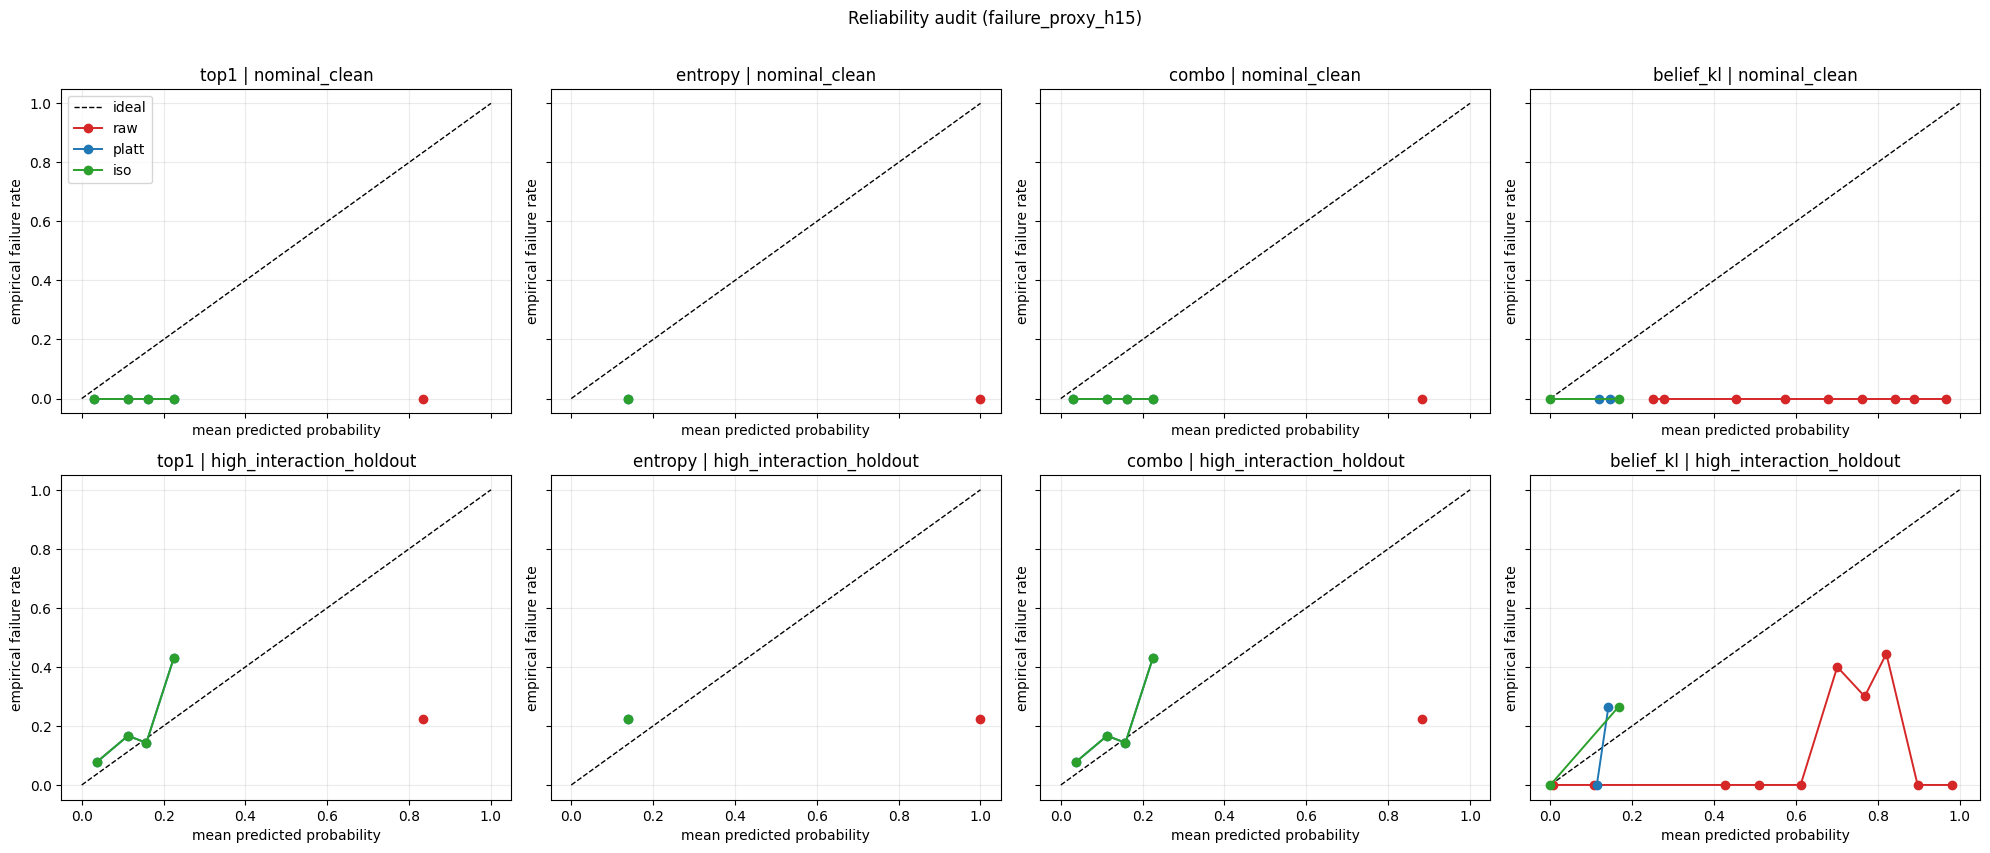

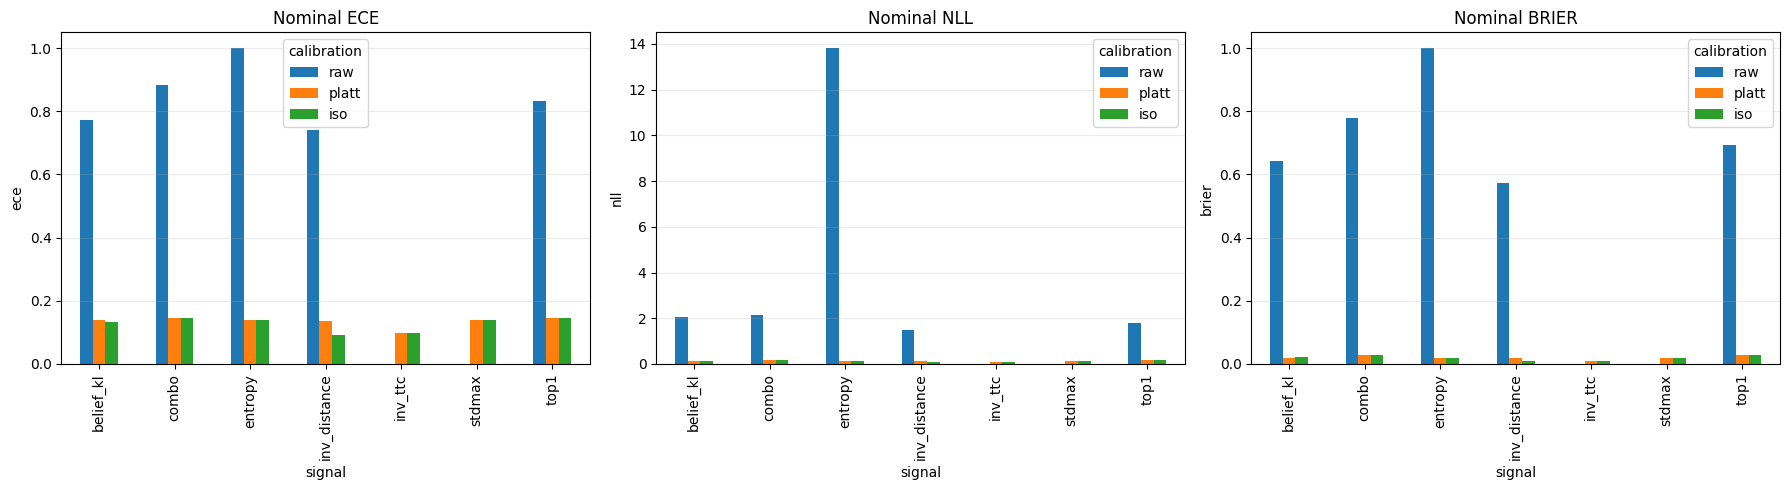

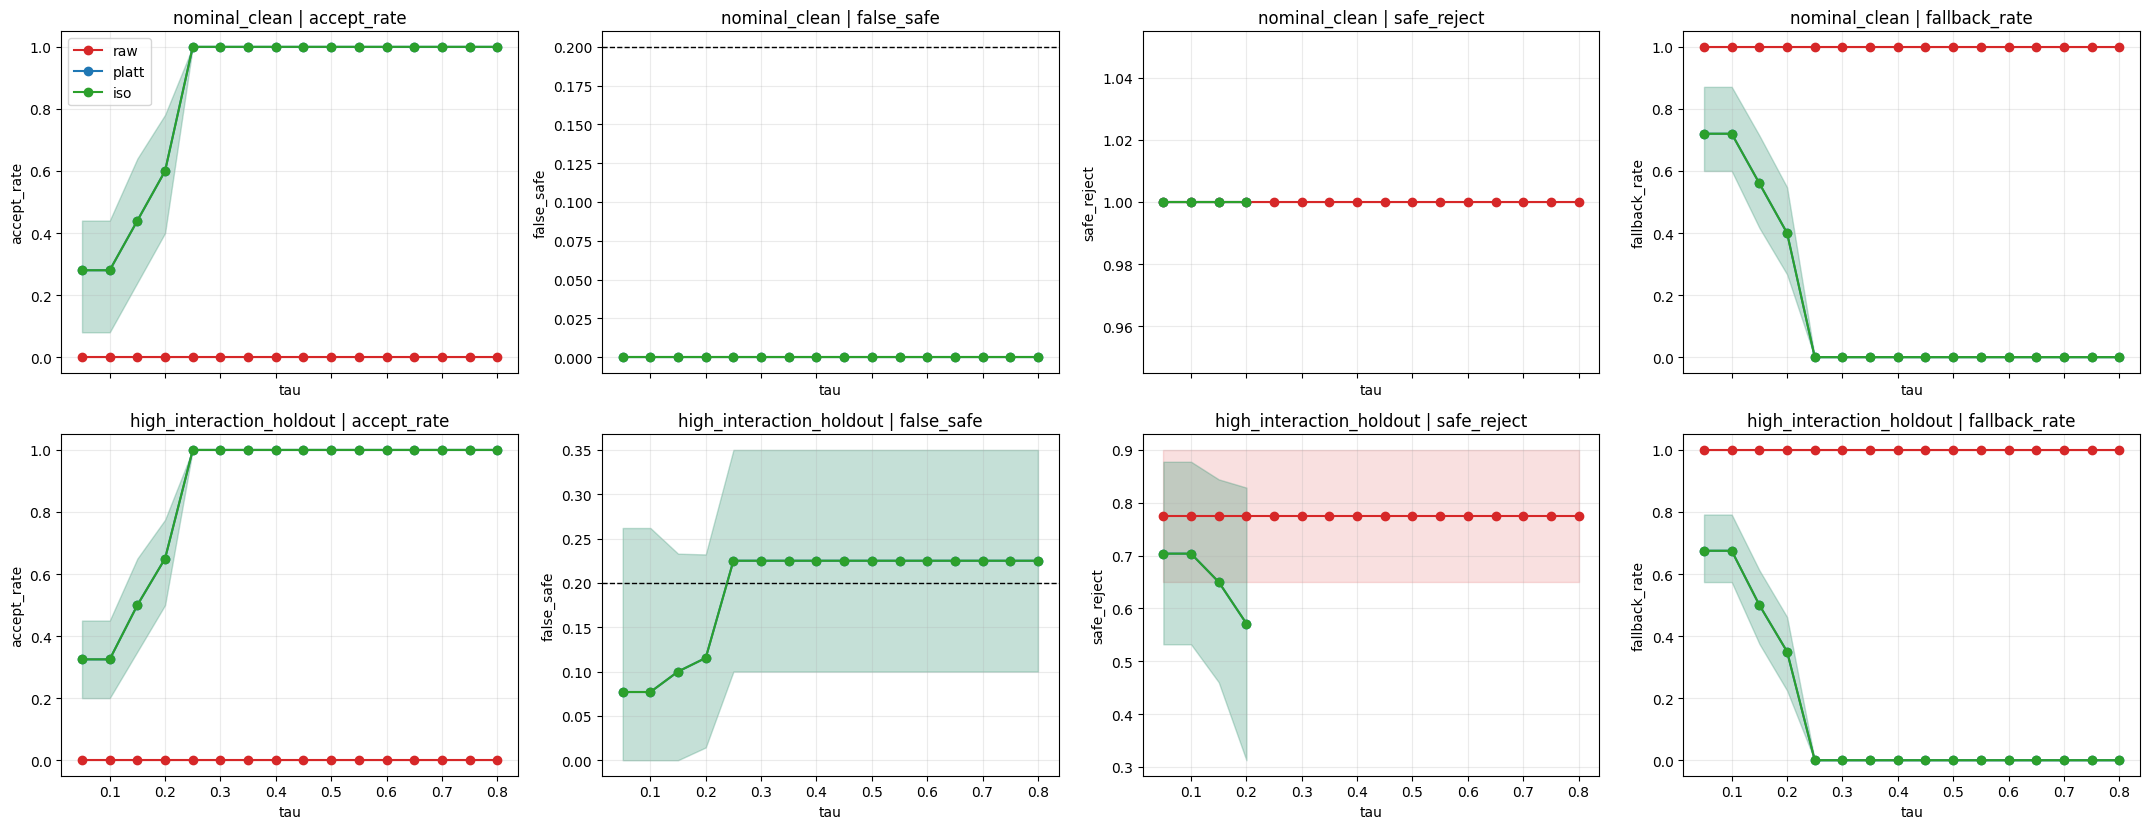

figure_paths = {'cross_signal_reliability': '/content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_reliability.png', 'cross_signal_nominal_metrics': '/content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_nominal_metrics.png', 'cross_signal_tau_sweep': '/content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_tau_sweep.png'}


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

figure_paths = {}

plot_planners = sorted(metrics_df['planner_variant'].astype(str).unique().tolist())[:2]
plot_shifts = ['nominal_clean']
non_nom = [x for x in sorted(metrics_df['shift_suite'].astype(str).unique().tolist()) if x != 'nominal_clean']
if len(non_nom) > 0:
    plot_shifts.append(non_nom[0])

# Plot 1: Reliability for combo (raw vs platt) across planners and domains.
base_signal = 'combo' if 'combo' in set(metrics_df['signal'].astype(str)) else str(metrics_df['signal'].astype(str).iloc[0])
if len(plot_planners) > 0:
    fig, axes = plt.subplots(len(plot_planners), len(plot_shifts), figsize=(5.2 * len(plot_shifts), 4.3 * len(plot_planners)), sharex=True, sharey=True)
    if len(plot_planners) == 1 and len(plot_shifts) == 1:
        axes = np.asarray([[axes]])
    elif len(plot_planners) == 1:
        axes = np.asarray([axes])
    elif len(plot_shifts) == 1:
        axes = np.asarray([[a] for a in axes])

    for i, planner in enumerate(plot_planners):
        for j, shift in enumerate(plot_shifts):
            ax = axes[i, j]
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='ideal')
            sub = eval_df[
                eval_df['planner_variant'].astype(str).eq(str(planner))
                & eval_df['shift_suite'].astype(str).eq(str(shift))
            ].copy()
            for cal, color in [('raw', 'tab:red'), ('platt', 'tab:blue'), ('iso', 'tab:green')]:
                col = variant_to_column.get(f'{base_signal}:{cal}', '')
                if (not col) or (col not in sub.columns) or sub.empty:
                    continue
                p = _clip_prob(sub[col])
                y = (_safe_float(sub[FOCUS_LABEL], default=0.0) > 0.5).astype(float)
                bins = np.linspace(0.0, 1.0, int(cfg.uq_eval_probability_bins) + 1)
                xs, ys = [], []
                for k in range(len(bins) - 1):
                    lo, hi = bins[k], bins[k + 1]
                    m = (p >= lo) & (p <= hi) if (k == len(bins) - 2) else (p >= lo) & (p < hi)
                    if not np.any(m):
                        continue
                    xs.append(float(np.mean(p[m])))
                    ys.append(float(np.mean(y[m])))
                if len(xs) > 0:
                    ax.plot(xs, ys, marker='o', linewidth=1.4, color=color, label=cal)
            ax.set_title(f'{planner} | {shift} | {base_signal}')
            ax.set_xlabel('mean predicted probability')
            ax.set_ylabel('empirical failure rate')
            ax.grid(alpha=0.25)
            if i == 0 and j == 0:
                ax.legend(loc='best')

    fig.suptitle(f'Reliability audit across planners ({FOCUS_LABEL})', y=1.01)
    fig.tight_layout()
    path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_reliability.png'
    fig.savefig(path, dpi=170, bbox_inches='tight')
    figure_paths['cross_signal_reliability'] = path
    plt.show()

# Plot 2: Nominal ECE comparison (planner x signal x calibration).
nominal = domain_compare_df[domain_compare_df['domain'].astype(str).eq('nominal')].copy()
if not nominal.empty:
    best_nominal = (
        nominal
        .sort_values(['planner_variant', 'signal', 'ece'])
        .groupby(['planner_variant', 'signal'], as_index=False)
        .first()
    )
    fig, ax = plt.subplots(1, 1, figsize=(11, 5))
    pivot = best_nominal.pivot(index='planner_variant', columns='signal', values='ece').sort_index()
    pivot.plot(kind='bar', ax=ax)
    ax.set_title('Best nominal ECE by planner and signal (lower is better)')
    ax.set_xlabel('planner_variant')
    ax.set_ylabel('ECE')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_nominal_ece_by_planner.png'
    fig.savefig(path, dpi=170, bbox_inches='tight')
    figure_paths['cross_signal_nominal_ece_by_planner'] = path
    plt.show()

# Plot 3: Tau sweep at base signal for each planner (platt when available).
plot_signal = 'combo' if 'combo' in set(tau_sweep_df['signal'].astype(str)) else base_signal
plot_cal = 'platt' if 'platt' in set(tau_sweep_df['calibration'].astype(str)) else 'raw'
sub = tau_sweep_df[
    tau_sweep_df['signal'].astype(str).eq(plot_signal)
    & tau_sweep_df['calibration'].astype(str).eq(plot_cal)
].copy()

if not sub.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
    for planner, grp in sub.groupby('planner_variant', sort=False):
        nominal_grp = grp[grp['shift_suite'].astype(str).eq('nominal_clean')]
        if nominal_grp.empty:
            nominal_grp = grp.copy()
        nominal_grp = nominal_grp.sort_values('tau')
        axes[0].plot(nominal_grp['tau'], nominal_grp['false_safe'], marker='o', linewidth=1.3, label=str(planner))
        axes[1].plot(nominal_grp['tau'], nominal_grp['fallback_rate'], marker='o', linewidth=1.3, label=str(planner))

    axes[0].axhline(float(RISK_BUDGET_TAU), color='k', linestyle='--', linewidth=1)
    axes[0].set_title(f'False-safe vs tau ({plot_signal}:{plot_cal})')
    axes[0].set_xlabel('tau')
    axes[0].set_ylabel('false_safe')
    axes[0].grid(alpha=0.25)

    axes[1].set_title(f'Fallback rate vs tau ({plot_signal}:{plot_cal})')
    axes[1].set_xlabel('tau')
    axes[1].set_ylabel('fallback_rate')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='best')

    fig.tight_layout()
    path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_tau_sweep_by_planner.png'
    fig.savefig(path, dpi=170, bbox_inches='tight')
    figure_paths['cross_signal_tau_sweep_by_planner'] = path
    plt.show()

print('figure_paths =', figure_paths)


## Step 9 - Export Artifacts + Contract Manifest


In [28]:
from src.workflows import write_contract_storage_mirror, write_notebook_contract_manifest

metrics_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_metrics.csv'
tau_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_tau_sweep.csv'
domain_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_domain_compare.csv'
budget_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_tau_at_budget.csv'
calib_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_calibrator_summary.csv'
pred_export_path = f'{AUDIT_OUTPUT_PREFIX}_cross_signal_decision_predictions.parquet'

metrics_df.to_csv(metrics_path, index=False)
tau_sweep_df.to_csv(tau_path, index=False)
domain_compare_df.to_csv(domain_path, index=False)
if not tau_at_budget_df.empty:
    tau_at_budget_df.to_csv(budget_path, index=False)
calibrator_df.to_csv(calib_path, index=False)
work_df.to_parquet(pred_export_path, index=False)

artifact_paths = {
    'cross_signal_metrics': metrics_path,
    'cross_signal_tau_sweep': tau_path,
    'cross_signal_domain_compare': domain_path,
    'cross_signal_calibrator_summary': calib_path,
    'cross_signal_decision_predictions': pred_export_path,
    **figure_paths,
}
if not tau_at_budget_df.empty:
    artifact_paths['cross_signal_tau_at_budget'] = budget_path

extra = {
    'analysis_run_prefix': str(analysis_run_prefix),
    'audit_output_prefix': str(AUDIT_OUTPUT_PREFIX),
    'focus_label': str(FOCUS_LABEL),
    'risk_budget_tau': float(RISK_BUDGET_TAU),
    'bootstrap_samples': int(BOOTSTRAP_SAMPLES),
    'metric_rows': int(len(metrics_df)),
    'tau_rows': int(len(tau_sweep_df)),
    'inconclusive_tau_rows': int((tau_sweep_df['status'] == 'inconclusive').sum()) if not tau_sweep_df.empty else 0,
    'signal_count': int(metrics_df['signal'].nunique()) if not metrics_df.empty else 0,
    'planner_count': int(metrics_df['planner_variant'].nunique()) if 'planner_variant' in metrics_df.columns and (not metrics_df.empty) else 0,
    'figure_count': int(len(figure_paths)),
}

manifest_path = write_notebook_contract_manifest(
    run_prefix=cfg.run_prefix,
    run_tag=RUN_TAG,
    cfg=cfg,
    search_cfg=search_cfg,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    notebook_name=NOTEBOOK_NAME,
    stage='cross_signal_decision_audit_completed',
    repo_dir=REPO_DIR,
    git_commit=globals().get('_RISK_UQ_REPO_REV', ''),
    extra_fields=extra,
)

contract_paths = write_contract_storage_mirror(
    persist_root=PERSIST_ROOT,
    run_prefix=RUN_PREFIX,
    run_name=RUN_NAME,
    run_prefix_path=cfg.run_prefix,
    cfg=cfg,
    search_cfg=search_cfg,
    n_shards=N_SHARDS,
    shard_id=SHARD_ID,
    stage='cross_signal_decision_audit_completed',
    git_commit=str(globals().get('_RISK_UQ_REPO_REV', '')),
    resume_from_existing=bool(RESUME_FROM_EXISTING),
    run_enabled=bool(RUN_ENABLED),
    artifact_paths=artifact_paths,
    metrics_csv_path=metrics_path,
    extra_fields=extra,
)

print('manifest_path =', manifest_path)
print('contract_run_manifest =', contract_paths['contract_run_manifest'])
print('exported_artifacts:')
for k, v in sorted(artifact_paths.items()):
    print('-', k, '->', v)


manifest_path = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260301_043750_notebook_contract_manifest.json
contract_run_manifest = /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_risk_uq_20260301_043750/run_manifest.json
exported_artifacts:
- cross_signal_calibrator_summary -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_calibrator_summary.csv
- cross_signal_decision_predictions -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_decision_predictions.parquet
- cross_signal_domain_compare -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_domain_compare.csv
- cross_signal_metrics -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cross_signal_metrics.csv
- cross_signal_nominal_metrics -> /content/drive/MyDrive/waymax_experiments/risk_uq_runs/v1/risk_uq_20260228_165758_cros

## Step 10 - Final Summary


In [29]:
import numpy as np

print('=== Final Summary (Cross-Signal Decision Audit) ===')
print('focus_label =', FOCUS_LABEL, '| tau =', RISK_BUDGET_TAU)
print('planner_variants =', sorted(metrics_df['planner_variant'].astype(str).unique().tolist()))
print('signals_evaluated =', sorted(metrics_df['signal'].astype(str).unique().tolist()))
print('inconclusive_tau_rows =', int((tau_sweep_df['status'] == 'inconclusive').sum()) if not tau_sweep_df.empty else 0)

nominal_df = metrics_df[metrics_df['domain'].astype(str).eq('nominal')].copy()
if nominal_df.empty:
    nominal_df = metrics_df.copy()

for planner in sorted(nominal_df['planner_variant'].astype(str).unique().tolist()):
    sub = nominal_df[nominal_df['planner_variant'].astype(str).eq(str(planner))].copy()
    if sub.empty:
        continue
    best = sub.sort_values(['ece', 'nll', 'brier', 'auroc'], ascending=[True, True, True, False]).head(1)
    if best.empty:
        continue
    row = best.iloc[0]
    print(f"[best nominal variant | {planner}] {row['signal']}:{row['calibration']}")
    print('  AUROC=', f"{float(row['auroc']):.4f}",
          'AUPRC=', f"{float(row['auprc']):.4f}",
          'within_step_auc=', f"{float(row['within_step_auc']):.4f}",
          'ECE=', f"{float(row['ece']):.4f}",
          'NLL=', f"{float(row['nll']):.4f}",
          'Brier=', f"{float(row['brier']):.4f}")

if not tau_at_budget_df.empty:
    budget_view = tau_at_budget_df.copy()
    preferred_signals = ['combo', 'racp_style', 'ccmpc_style', 'radius_style']
    budget_view = budget_view[budget_view['signal'].astype(str).isin(preferred_signals)]
    if budget_view.empty:
        budget_view = tau_at_budget_df.copy()
    cols = [
        'planner_variant', 'shift_suite', 'signal', 'calibration', 'tau', 'accept_rate',
        'false_safe', 'safe_reject', 'feasible_set_rate', 'fallback_rate', 'status', 'inconclusive_reason'
    ]
    cols = [c for c in cols if c in budget_view.columns]
    print('\n[decision diagnostics near tau budget]')
    display(budget_view.loc[:, cols].head(80))

print('\nInterpretation guideline:')
print('- Compare best calibrated variants per planner to test whether calibration-to-decision transfer is planner-dependent.')
print('- `racp_style` / `ccmpc_style` / `radius_style` are method-inspired proxy formulations for cross-planner decision diagnostics.')
print('- Inconclusive rows indicate insufficient positive mass or accept/reject counts for stable claims.')


=== Final Summary (Cross-Signal Decision Audit) ===
focus_label = failure_proxy_h15 | tau = 0.2
signals_evaluated = ['belief_kl', 'combo', 'entropy', 'inv_distance', 'inv_ttc', 'stdmax', 'top1']
inconclusive_tau_rows = 635
[best nominal variant]  inv_ttc:raw
  AUROC= nan AUPRC= nan within_step_auc= nan ECE= 0.0000 NLL= 0.0000 Brier= 0.0000
\n[decision diagnostics near tau budget]


,shift_suite,signal,calibration,tau,accept_rate,false_safe,safe_reject,feasible_set_rate,fallback_rate,status,inconclusive_reason
3,high_interaction_holdout,combo,iso,0.2,0.65,0.115385,0.571429,0.65,0.35,ok,
4,high_interaction_holdout,combo,platt,0.2,0.65,0.115385,0.571429,0.65,0.35,ok,
5,high_interaction_holdout,combo,raw,0.2,0.00,NaN,0.775000,0.00,1.00,inconclusive,low_accept_count
24,nominal_clean,combo,iso,0.2,0.60,0.000000,1.000000,0.60,0.40,inconclusive,low_positives;low_step_count
25,nominal_clean,combo,platt,0.2,0.60,0.000000,1.000000,0.60,0.40,inconclusive,low_positives;low_step_count
26,nominal_clean,combo,raw,0.2,0.00,NaN,1.000000,0.00,1.00,inconclusive,low_positives;low_accept_count;low_step_count


\nInterpretation guideline:
- If calibration lowers ECE/NLL/Brier and reduces false_safe at fixed tau, risk is more decision-grade.
- If false_safe and safe_reject are both high, threshold rule and/or signal quality needs redesign.
- Inconclusive rows indicate insufficient positive mass or accept/reject counts for stable claims.
